In [1]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold
import scipy.stats as stat
import pylab
import xgboost as xgb
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import RepeatedKFold


In [2]:
X = pd.read_csv("X_train_42.csv")
y = pd.read_csv("y_train_42.csv")
X_test = pd.read_csv("X_test_42.csv")
y_test = pd.read_csv("y_test_42.csv")

In [3]:
X = X.drop(["Latitude [N]","Longitude [E]",'Date'],axis=1)
X.head()

,SST,SSS,MLD
0,27.201605,31.981873,2.899140
1,29.628925,33.506270,2.694727
2,27.011170,36.405530,3.536116
3,28.216042,35.670033,2.899140
4,28.087864,33.211770,3.318513


In [4]:
X_test = X_test.drop(["Latitude [N]","Longitude [E]",'Date'],axis=1)
X_test.head()

,SST,SSS,MLD
0,28.397686,35.494553,2.864948
1,30.888730,32.653280,2.424081
2,30.608204,36.271248,2.437504
3,26.147617,35.909603,2.538857
4,28.322245,33.063755,2.410475


In [5]:
X.describe()

,SST,SSS,MLD
count,890.000000,890.000000,890.000000
mean,28.518621,34.262966,2.787980
std,1.618192,1.635131,0.387185
min,23.588457,29.729607,2.339524
25%,27.577349,32.891323,2.476725
50%,28.575304,33.928953,2.652616
75%,29.708397,35.995056,3.032671
max,31.681967,37.305824,4.033519


In [6]:
X_test.describe()

,SST,SSS,MLD
count,223.000000,223.000000,223.000000
mean,28.567642,34.350944,2.794107
std,1.736527,1.555499,0.416895
min,24.073336,30.549028,2.339524
25%,27.683188,33.115637,2.502043
50%,28.860592,34.055603,2.663311
75%,29.800554,35.886715,2.919922
max,32.728630,38.071842,4.022649


In [7]:
y.shape

(890, 1)

In [8]:
y_test.describe()

,TA
count,223.000000
mean,2252.464340
std,112.926923
min,1945.347046
25%,2189.367334
50%,2233.100000
75%,2335.580000
max,2517.617899


In [9]:
sc = StandardScaler()
X = sc.fit_transform(X)
X_test = sc.transform(X_test)

In [10]:
# y = np.log(y)
# y_test = sc.transform(y_test)

In [11]:
kfold = KFold(n_splits=10)
# kfold = RepeatedKFold(n_splits=10,n_repeats=5,random_state=42)

In [12]:
# 

# param ={'lambda': 0.4296499385290689,
#  'alpha': 0.43838297214937116,
#  'subsample': 0.7498724267382368,
#  'booster': 'gbtree',
#  'colsample_bytree': 0.8999827351565879,
#  'n_estimators': 354,
#  'max_depth': 131,
#  'min_child_weight': 20,
#  'learning_rate': 0.019770659574797775,
#  'gamma': 0.0002649153094834086,
#  'grow_policy': 'lossguide'}

param = {
    'lambda': 0.6,                       # 🔸 Increase regularization (was 0.42)
    'alpha': 0.6,                        # 🔸 Increase L1 regularization (was 0.43)
    'subsample': 0.7,                   # 🔸 Slightly less data per tree → less variance
    'booster': 'gbtree',
    'colsample_bytree': 0.7,           # 🔸 Lower feature sampling → less overfitting
    'n_estimators': 500,               # 🔸 Slightly fewer rounds
    'max_depth': 100,                  # 🔸 Reduce tree complexity
    'min_child_weight': 25,            # 🔸 Make trees more conservative
    'learning_rate': 0.025,            # 🔸 Slightly lower than before
    'gamma': 0.01,                     # 🔸 Increase split threshold
    'grow_policy': 'lossguide'
}






In [13]:
for train_ix, val_ix in kfold.split(X):
    X_train, X_val = X[train_ix], X[val_ix]
    y_train, y_val = y.iloc[train_ix], y.iloc[val_ix]
#     y_train, y_val = y[train_ix], y[val_ix]

    
#     model = xgb.XGBRegressor(random_state=42,eval_metric='rmse',n_jobs=-1)
    model = xgb.XGBRegressor(**param,n_jobs=-1,random_state=42,eval_metric='rmse')
    model.fit(X_train,y_train,eval_set=[(X_train,y_train),(X_val,y_val)])

[0]	validation_0-rmse:2193.62572	validation_1-rmse:2169.08995
[1]	validation_0-rmse:2138.94321	validation_1-rmse:2114.79201
[2]	validation_0-rmse:2085.68651	validation_1-rmse:2062.07577
[3]	validation_0-rmse:2033.86616	validation_1-rmse:2010.66511
[4]	validation_0-rmse:1983.28176	validation_1-rmse:1960.45098
[5]	validation_0-rmse:1933.92411	validation_1-rmse:1911.43576
[6]	validation_0-rmse:1885.68352	validation_1-rmse:1863.18850
[7]	validation_0-rmse:1838.84555	validation_1-rmse:1816.34375
[8]	validation_0-rmse:1793.10006	validation_1-rmse:1770.59134
[9]	validation_0-rmse:1748.38435	validation_1-rmse:1725.86855
[10]	validation_0-rmse:1704.84318	validation_1-rmse:1682.81093
[11]	validation_0-rmse:1662.53673	validation_1-rmse:1640.86207
[12]	validation_0-rmse:1621.15591	validation_1-rmse:1599.83682
[13]	validation_0-rmse:1580.84823	validation_1-rmse:1559.52232
[14]	validation_0-rmse:1541.43956	validation_1-rmse:1520.45225
[15]	validation_0-rmse:1503.05079	validation_1-rmse:1482.52943
[1

In [14]:
from sklearn.metrics import mean_absolute_error
import scipy.stats as st

In [15]:
y_pred = model.predict(X_test)

r21 = r2_score(y_test,y_pred)
print(r21)
# rmse = mean_squared_error(y_test,y_pred,squared=False)
# print(rmse)
mse = mean_squared_error(y_test,y_pred,squared=False)
print(mse)
# mae = mean_absolute_error(y_test,y_pred)
# print(mae)
# p_value = stat.ttest_ind(y_test,y_pred,alternative='less')
# print(p_value)

0.800555099335586
50.31911772780374


In [16]:
y_pred = pd.DataFrame(y_pred)
y_pred.columns = ["TA_pred"]

In [17]:
r = st.pearsonr(y_test["TA"],y_pred["TA_pred"])
print(r)

PearsonRResult(statistic=0.896544098475125, pvalue=4.183787534280027e-80)


In [18]:
y_pred_train = model.predict(X)

r2_tr = r2_score(y,y_pred_train)
print(r2_tr)
rmse_tr = mean_squared_error(y,y_pred_train,squared=False)
print(rmse_tr)
# mse = mean_absolute_error(y,y_pred_train)
# print(mse)

0.8155754433793716
49.356245721778535


In [19]:
y_pred_train = pd.DataFrame(y_pred_train)
y_pred_train.columns = ["TA_train_pred"]

In [20]:
rr = st.pearsonr(y["TA"],y_pred_train["TA_train_pred"])
print(rr)

PearsonRResult(statistic=0.9044854984459862, pvalue=0.0)


/tmp/ipykernel_9230/1985488398.py:14: MatplotlibDeprecationWarning: Passing the emit parameter of set_xlim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  axn[0].set_xlim(1900,2600,50)
/tmp/ipykernel_9230/1985488398.py:15: MatplotlibDeprecationWarning: Passing the emit parameter of set_ylim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  axn[0].set_ylim(1900,2600,50)
/tmp/ipykernel_9230/1985488398.py:22: MatplotlibDeprecationWarning: Passing the emit parameter of set_xlim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  axn[1].set_xlim(1900,2600,50)
/tmp/ipykernel_9230/1985488398.py:23: MatplotlibDeprecationWarning: Passing the emit parameter of set_ylim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  axn[1].set

Text(0.01, 0.9, 'RMSE = 50.32 (μmol kg$^{-1}$)')

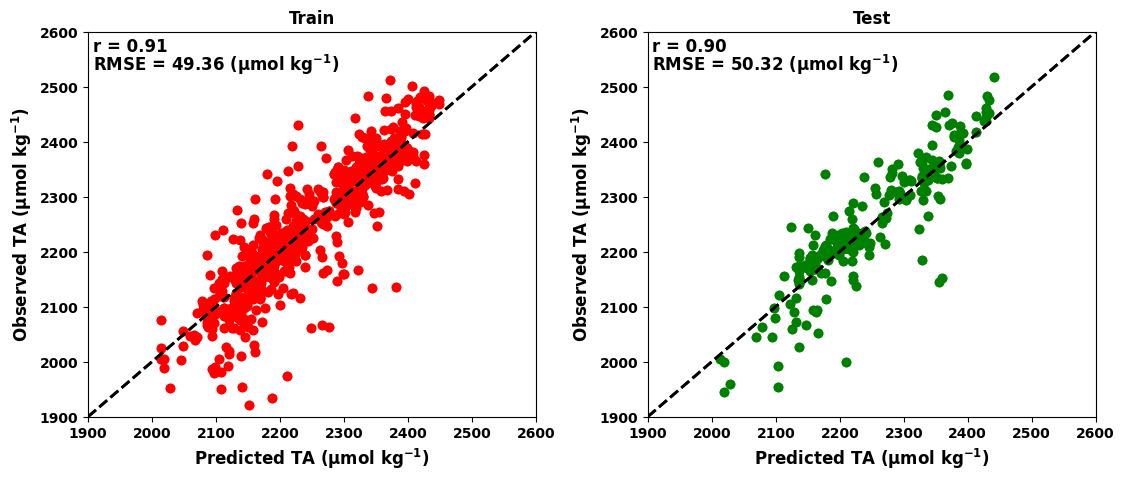

In [21]:
plt.rcParams["font.weight"] = "bold"
fig, axn = plt.subplots(1, 2, figsize=(13,5))
fig.subplots_adjust(hspace=0.16, wspace=0.25)
axn = axn.ravel()
aa = [1900,2600]
bb = [1900,2600]

aa1 = [1900,2600]
bb1 = [1900,2600]
for i in range(2):
    axn[0].scatter(y_pred_train,y,c='r')
    axn[0].set_xlabel("Predicted TA (\u03BCmol kg$^{-1}$)",fontsize=12,fontweight="bold")
    axn[0].set_ylabel("Observed TA (\u03BCmol kg$^{-1}$)",fontsize=12,fontweight="bold")
    axn[0].set_xlim(1900,2600,50)
    axn[0].set_ylim(1900,2600,50)
    axn[0].plot(aa,bb,linewidth=2,c='k',linestyle="--")
    axn[0].set_title("Train",fontsize=12,fontweight="bold")
    
    axn[1].scatter(y_pred,y_test,c='g')
    axn[1].set_xlabel("Predicted TA (\u03BCmol kg$^{-1}$)",fontsize=12,fontweight="bold")
    axn[1].set_ylabel("Observed TA (\u03BCmol kg$^{-1}$)",fontsize=12,fontweight="bold")
    axn[1].set_xlim(1900,2600,50)
    axn[1].set_ylim(1900,2600,50)
    axn[1].plot(aa1,bb1,linewidth=2,c='k',linestyle="--")
    axn[1].set_title("Test",fontsize=12,fontweight="bold")

axn[0].text(0.01,0.95,"r = 0.91",transform=axn[0].transAxes,fontsize=12,fontweight="bold",zorder=10)
axn[0].text(0.01,0.9,"RMSE = 49.36 (\u03BCmol kg$^{-1}$)",transform=axn[0].transAxes,fontsize=12,fontweight="bold",zorder=10)

axn[1].text(0.01,0.95,"r = 0.90",transform=axn[1].transAxes,fontsize=12,fontweight="bold",zorder=10)
axn[1].text(0.01,0.9,"RMSE = 50.32 (\u03BCmol kg$^{-1}$)",transform=axn[1].transAxes,fontsize=12,fontweight="bold",zorder=10)

# plt.savefig("Model_performance.png",dpi=600,orientation='potrait', bbox_inches='tight')

In [22]:
from matplotlib import pyplot

In [23]:
results = model.evals_result()
# results

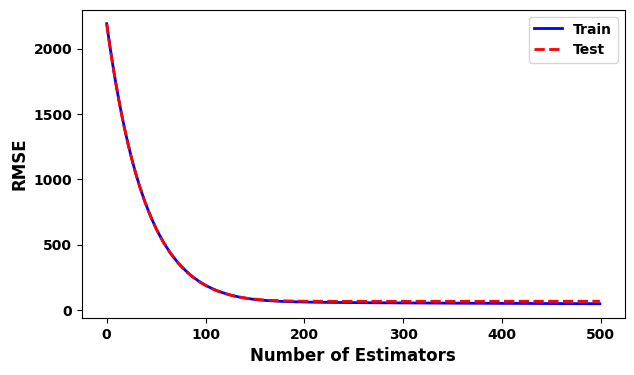

In [24]:
plt.rcParams["font.weight"] = "bold"
plt.figure(figsize=(7,4))
# plot learning curves
pyplot.plot(results['validation_0']['rmse'], label='Train',linewidth=2,c='b')
pyplot.plot(results['validation_1']['rmse'], label='Test',linestyle="--",linewidth=2,c='r')
# show the legend
pyplot.legend()


pyplot.xlabel("Number of Estimators",fontsize=12,fontweight="bold")
pyplot.ylabel("RMSE",fontsize=12,fontweight="bold")
# plt.savefig("Train_Test_plot.png",dpi=600)
# show the plot
pyplot.show()

In [31]:
# XGB_pred = pd.DataFrame(y_pred)
# XGB_pred.columns = ['pCO2XGB_testp']

# XGB_pred_train = pd.DataFrame(y_pred_train)
# XGB_pred_train.columns = ['pCO2XGB_trainp']

# XGB_pred.to_csv("XGBpred_test.csv",index=False)

# XGB_pred_train.to_csv("XGBpred_train.csv",index=False)

import shap

explainer = shap.KernelExplainer(model.predict,X)

shap_values = explainer.shap_values(X_test,nsamples=10,n_jobs=-1)

shap.summary_plot(shap_values,X_test)


X_test

shap_values

In [26]:
from joblib import dump
from joblib import load

In [27]:
# save model to file
# dump(model,"xgb_best.joblib_TA.dat")

['xgb_best.joblib_TA.dat']

In [ ]:
# model1 = load("xgb_BoB_withoutLONLAT22.joblib.dat")

In [ ]:
# model1.get_params()

In [ ]:
# y_pred_train = model1.predict(X)
# y_pred_test = model1.predict(X_test)

In [ ]:
# r2_train = r2_score(y,y_pred_train)
# print(r2_train)
# rmse_train = mean_squared_error(y,y_pred_train,squared=False)
# print(rmse_train)

In [ ]:
# r2_test = r2_score(y_test,y_pred_test)
# print(r2_test)
# rmse_test = mean_squared_error(y_test,y_pred_test,squared=False)
# print(rmse_test)

In [ ]:
# XGB_pred = pd.DataFrame(y_pred)
# XGB_pred.columns = ['pCO2XGB_testp']

# XGB_pred_train = pd.DataFrame(y_pred_train)
# XGB_pred_train.columns = ['pCO2XGB_trainp']

# XGB_pred.to_csv("XGBpred_test.csv",index=False)

# XGB_pred_train.to_csv("XGBpred_train.csv",index=False)

X_test[:,2:]

## RAMA 15,90 pCO2 predictions

In [ ]:
df22 = pd.read_csv('Input_values_1590.csv',usecols=["SSS","SST"])

In [ ]:
df22

In [ ]:
df22.SST.plot()

In [ ]:
y_predSat = model.predict(df22)

In [ ]:
y_predSat
